# Overview

Scaling of autoregressive predictors across N and K range

In [1]:
import sys
sys.path.append('/home/cg5763/icl')
from base.estimators.markov_model_ar import init_all_estimators
from base.tasks.markov_model import MarkovModel
from ml_collections import ConfigDict
import seaborn as sns
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

plt.rcParams.update({
    # "legend.frameon": False,
    # "text.usetex": True,
    # "font.family": "serif",
    # "font.size": 8,
    "figure.figsize": (3, 2),
    # 'axes.titlesize': 8,
    # 'figure.dpi': 150,
    # "pdf.fonttype": 3,   # embed TrueType (Type 42) instead of Type 3
    # "ps.fonttype": 3,
})

import matplotlib as mpl

mpl.rcParams.update({

    # --- Use LaTeX for all text ---
    "text.usetex": True,

    # Ensure Times-like fonts consistent with APS papers
    "font.family": "serif",

    # # LaTeX preamble
    # "text.latex.preamble": r"""
    #     \usepackage{amsmath}
    #     \usepackage{amssymb}
    #     \usepackage{newtxtext}
    #     \usepackage{newtxmath}
    # """,

    # --- Font sizes ---
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,

    # --- Axes ---
    "axes.linewidth": 0.8,
    "axes.labelpad": 2,

    # --- Ticks (APS style) ---
    "xtick.direction": "in",
    "ytick.direction": "in",
    # "xtick.top": True,
    # "ytick.right": True,

    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,

    "xtick.major.pad": 1.5,
    "ytick.major.pad": 1.5,

    # --- Lines ---
    "lines.linewidth": 1.0,
    "lines.markersize": 3,

    # --- Legend ---
    "legend.frameon": False,
    "legend.handlelength": 1.2,
    "legend.borderpad": 0.2,

    # --- Export ---
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

plot_dir=Path("./")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def log_heatmap(
    pvt,
    ax=None,
    vmin=None,
    vmax=None,
    vcenter=None,
    cmap="viridis",
    rasterized=True,
    cbar=False,
    cbar_kwargs=None,
):
    if ax is None:
        ax = plt.gca()

    if cbar_kwargs is None:
        cbar_kwargs = {}

    X = np.asarray(pvt.columns, dtype=float)
    Y = np.asarray(pvt.index, dtype=float)
    Z = pvt.values

    def log_edges(vals):
        vals = np.asarray(vals, float)
        ratios = vals[1:] / vals[:-1]
        edges = np.empty(len(vals) + 1)
        edges[1:-1] = np.sqrt(vals[:-1] * vals[1:])
        edges[0] = vals[0] / np.sqrt(ratios[0])
        edges[-1] = vals[-1] * np.sqrt(ratios[-1])
        return edges

    x_edges = log_edges(X)
    y_edges = log_edges(Y)

    # --- normalization ---
    norm = None
    if vcenter is not None:
        if vmin is None:
            vmin = np.nanmin(Z)
        if vmax is None:
            vmax = np.nanmax(Z)
        if not (vmin < vcenter < vmax):
            raise ValueError("Require vmin < vcenter < vmax for TwoSlopeNorm.")
        norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    qm = ax.pcolormesh(
        x_edges,
        y_edges,
        Z,
        shading="auto",
        cmap=cmap,
        norm=norm,
        vmin=None if norm is not None else vmin,
        vmax=None if norm is not None else vmax,
        edgecolors="none",
        linewidth=0,
        antialiased=False,
        rasterized=rasterized,
    )

    ax.set_xscale("log")
    ax.set_yscale("log", base=2)

    for spine in ax.spines.values():
        spine.set_visible(False)

    cb = None
    if cbar:
        cb = ax.figure.colorbar(qm, ax=ax, **cbar_kwargs)

    return ax, qm, cb

In [3]:
config = ConfigDict()
config.task = ConfigDict()
config.task.vocab_size = 10
config.task.task_pool = None
config.task.n_tasks = 0
config.task.alpha = 1.0
config.task.device = 'cuda'
config.task.system_device = 'cuda'

In [4]:
import gc
gc.collect()
torch.cuda.empty_cache()

2-Gen fluctuations

In [10]:
N = 2**8
B = 2**14
config.task.n_tasks = 2**8
task_model = MarkovModel(config.task)
config.task.task_pool = task_model.task_pool

out = {
    'name': [],
    'loss': [],
}

for task_seed in [0]:
    config.task.seed = task_seed
    task_model = MarkovModel(config.task)
    estimators = init_all_estimators(config, task_model.task_pool.float(), task_model.stat_dist.float())
    for est in estimators:
        x, y, tasks = task_model.get_batch(B, N, return_tasks=True)
        _, loss = est(x, y, reduction='none')
        loss = loss.cpu().numpy().mean(-1)
        tasks = tasks.cpu().numpy()[:, -1]
        loss = loss[tasks == 0]
        out['name'] += [est.name] * len(loss)
        out['loss'] += loss.tolist()

out = pd.DataFrame(out)

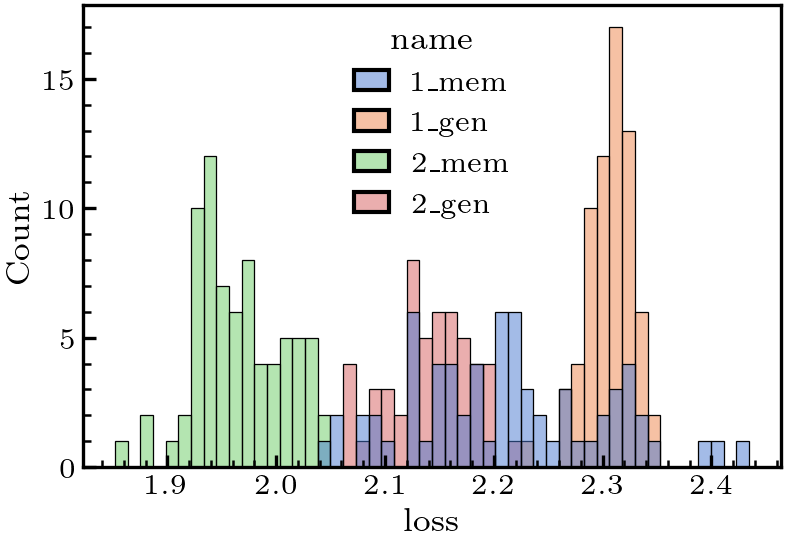

In [11]:
ax = sns.histplot(data=out, x='loss', hue='name', palette='muted', bins=50)

Original Work

In [ ]:
out = {
    'name': [],
    'loss': [],
    'K': [],
    'N': [],
    'task_seed': []
}

N = 2**10
B = 2**10
repeat = 2**4
log_min_K = 1
log_max_K = 12
base = 2
config.task.n_tasks = int(base**log_max_K)
task_model = MarkovModel(config.task)
config.task.task_pool = task_model.task_pool

for task_seed in range(2**3):
    for K in np.logspace(log_min_K, log_max_K, base = base, num = log_max_K-log_min_K+1, dtype = int).tolist():
        config.task.n_tasks = K
        config.task.seed = task_seed
        task_model = MarkovModel(config.task)
        estimators = init_all_estimators(config, task_model.task_pool.float(), task_model.stat_dist.float())
        loss = {}
        for _ in range(repeat):
            x, y = task_model.get_batch(B, N)
            for est in estimators:
                _, _loss = est(x, y, reduction='none')
                try:
                    loss[est.name] += _loss
                except KeyError:
                    loss[est.name] = _loss
        for est in estimators:
            _loss = loss[est.name]
            for n in range(N):
                out['name'].append(est.name)
                out['loss'].append(_loss[:, n].sum().item()/(repeat*B))
                out['K'].append(K)
                out['N'].append(n)
                out['task_seed'].append(task_seed)
out = pd.DataFrame(out)
out.to_csv('predictor_loss.csv', index=False)

In [63]:
df = pd.read_csv('predictor_loss.csv')
df['N'] = df['N']+1
values = {}
for est in df['name'].unique():
    _df = df[df['name'] == est].pivot_table(index='K', columns='N', values='loss', aggfunc='mean')
    values[est] = _df
    values[est+'_ar'] = _df.sort_index(axis=1).cumsum(axis=1)/np.arange(1, _df.shape[1]+1)

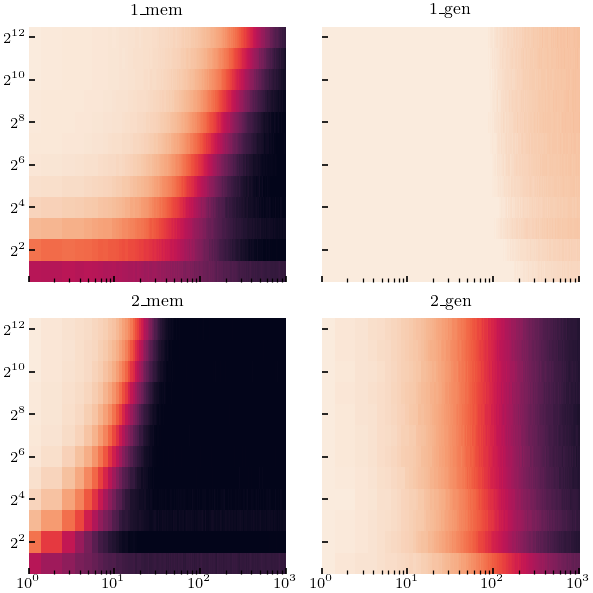

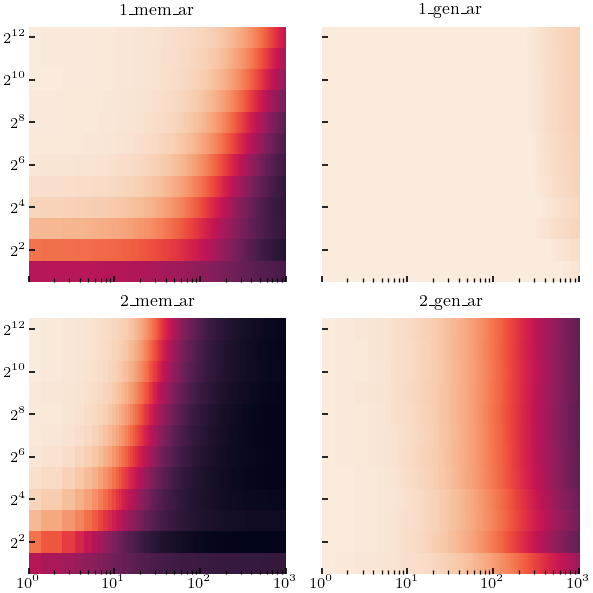

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(4, 4), sharex=True, sharey=True, layout='constrained')
vmin = 1.93
vmax = np.log(10)
for i, est in enumerate(df['name'].unique()):
    ax = axes[i//2, i%2]
    log_heatmap(values[est], vmin=vmin, vmax=vmax, ax=ax, cmap='rocket')
    ax.set_title(est)
    ax.set_xlim(left=1)

fig, axes = plt.subplots(2, 2, figsize=(4, 4), sharex=True, sharey=True, layout='constrained')
vmin = 1.93
vmax = np.log(10)
for i, est in enumerate(df['name'].unique()):
    ax = axes[i//2, i%2]
    _, _, cbar = log_heatmap(values[est+'_ar'], vmin=vmin, vmax=vmax, ax=ax, cmap='rocket')
    ax.set_title(est+'_ar')
    ax.set_xlim(left=1)


Text(0.5, 1.0, '1_mem - 2_gen')

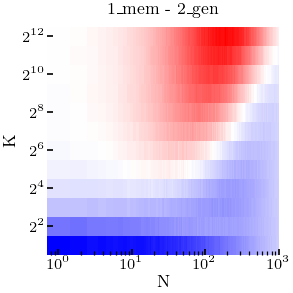

In [9]:
fig, ax = plt.subplots(figsize=(2, 2), layout='constrained')
log_heatmap(values['1_mem']-values['2_gen'], ax=ax, cmap='bwr', vcenter=0)
ax.set_xlabel('N')
ax.set_ylabel('K')
ax.set_title('1_mem - 2_gen')

Text(0.5, 1.0, '1_mem_ar - 2_gen_ar')

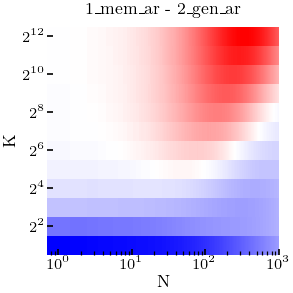

In [10]:
fig, ax = plt.subplots(figsize=(2, 2), layout='constrained')
log_heatmap(values['1_mem_ar']-values['2_gen_ar'], ax=ax, cmap='bwr', vcenter=0)
ax.set_xlabel('N')
ax.set_ylabel('K')
ax.set_title('1_mem_ar - 2_gen_ar')

Text(0.5, 1.0, '2_gen - 2_mem')

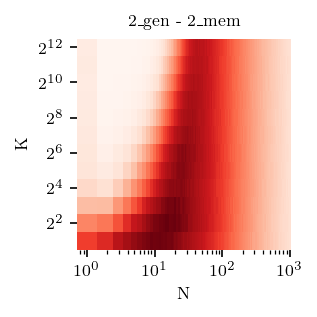

In [10]:
fig, ax = plt.subplots(figsize=(2, 2), layout='constrained')
log_heatmap(values['2_gen']-values['2_mem'], ax=ax, cmap='Reds', vmin = 0)
ax.set_xlabel('N')
ax.set_ylabel('K')
ax.set_title('2_gen - 2_mem')

In [58]:
df_avg = (
    df
    .groupby(['name', 'K', 'N'], as_index=False)['loss']
    .mean()
    .rename(columns={'loss': 'loss_mean'})
)

df_avg = df_avg.sort_values(['name', 'K', 'N'])

df_avg['loss_mean_ar'] = (
    df_avg
    .groupby(['name', 'K'])['loss_mean']
    .transform(lambda x: x.expanding().mean())
)

Text(0, 0.5, 'Loss')

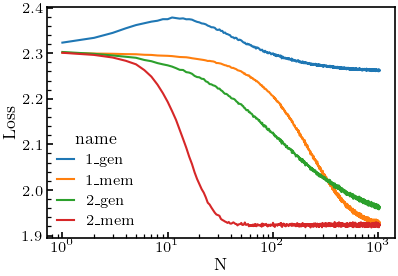

In [59]:
ax = sns.lineplot(data=df_avg[df_avg['K'].eq(2**8)], x='N', y='loss_mean', hue='name')
ax.set_xscale('log')
ax.set_ylabel('Loss')

Text(0, 0.5, 'Loss')

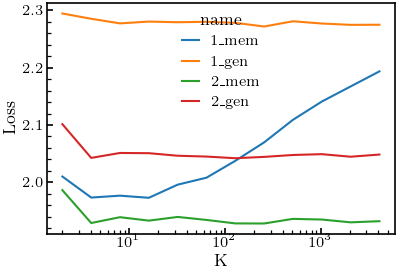

In [60]:
ax = sns.lineplot(data=df[df['N'].eq(2**8) & df['task_seed'].eq(3)], x='K', y='loss', hue='name')
ax.set_xscale('log')
ax.set_ylabel('Loss')

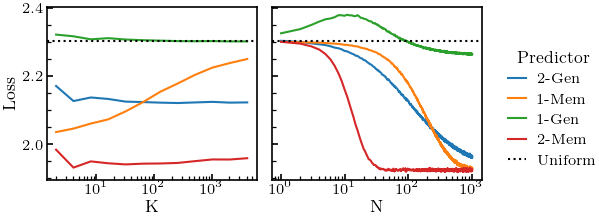

In [69]:
fig, axes = plt.subplots(1, 2, figsize = (4, 1.5), sharey=True, layout='constrained')

order = ["2_gen", "1_mem", "1_gen", "2_mem"]

df = df_avg[df_avg['N'].eq(2**8)].copy()
df["name"] = pd.Categorical(df["name"], categories=order, ordered=True)
df = df.sort_values("name")
ax = sns.lineplot(df, x = 'K', y = 'loss_mean_ar', hue = 'name', ax = axes[0])
ax.set_xscale('log')
ax.set_ylabel('Loss')
ax.axhline(-np.log(0.1), color='black', linestyle=':')
ax.legend().remove()

df = df_avg[df_avg['K'].eq(2**7)].copy()
df["name"] = pd.Categorical(df["name"], categories=order, ordered=True)
df = df.sort_values("name")
ax = sns.lineplot(df, x = 'N', y = 'loss_mean', hue = 'name', errorbar=None, ax = axes[1])
ax.axhline(-np.log(0.1), color='black', linestyle=':', label = 'uniform')
ax.set_xscale('log')
ax.set_ylabel('Loss')

handles, labels = ax.get_legend_handles_labels()
ax.legend().remove()
fig.legend(handles, [r'2-Gen', r'1-Mem', r'1-Gen', r'2-Mem', 'Uniform'], title = 'Predictor', frameon=False, loc='outside center right', borderaxespad=0.)
fig.savefig(plot_dir / 'predictor_scaling.svg', bbox_inches='tight')

# 2-Gen predictor

In [4]:
config = ConfigDict()
config.task = ConfigDict()
config.task.vocab_size = 10
config.task.task_pool = None
config.task.n_tasks = 0.0
config.task.alpha = 1.0
config.task.device = 'cuda'
config.task.system_device = 'cuda'

In [5]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# out = {
#     'name': [],
#     'loss': [],
#     'K': [],
#     'task_seed': []
# }

# N = 2**8
# B = 2**10
# repeat = 2**4
# log_min_K = 5
# log_max_K = 12
# base = 2
# config.task.n_tasks = float(base**log_max_K)
# task_model = MarkovModel(config.task)
# config.task.task_pool = task_model.task_pool

# for task_seed in range(2**4):
#     for K in np.logspace(log_min_K, log_max_K, base = base, num = log_max_K-log_min_K+1, dtype = float).tolist() + [float('inf')]:
#         config.task.n_tasks = K
#         config.task.seed = task_seed
#         task_model = MarkovModel(config.task)
#         estimators = init_all_estimators(config, task_model.task_pool.float(), task_model.stat_dist.float())
#         loss = {}
#         for _ in range(repeat):
#             x, y = task_model.get_batch(B, N)
#             est = estimators[-1] # 2-Gen only
#             _, _loss = est(x, y, reduction='mean')
#             try:
#                 loss[est.name] += _loss
#             except KeyError:
#                 loss[est.name] = _loss
#         for est in estimators[-1:]:
#             _loss = loss[est.name]
#             out['name'].append(est.name)
#             out['loss'].append(_loss.item()/repeat)
#             out['K'].append(K)
#             out['task_seed'].append(task_seed)
# out = pd.DataFrame(out)
# out.to_csv('autoregressive_predictor_loss.csv', index=False)

TypeError: torch.Size() takes an iterable of 'int' (item 0 is 'float')

<Axes: xlabel='K', ylabel='loss'>

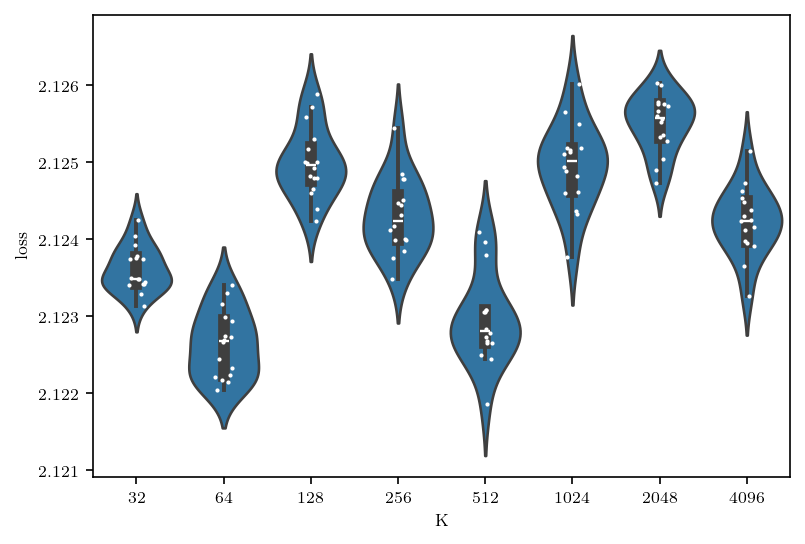

In [22]:
out = pd.read_csv('autoregressive_predictor_loss.csv')
ax = sns.violinplot(data=out, x='K', y='loss', density_norm='width')
sns.stripplot(data=out, x='K', y='loss', color='white', alpha=1, ax=ax, size=2)
# ax.set_xscale('log', base=2)

In [25]:
stats

,K,name,mean,std
0,32,2_gen,2.123615,0.000295
1,64,2_gen,2.122640,0.000434
2,128,2_gen,2.124995,0.000455
3,256,2_gen,2.124311,0.000496
4,512,2_gen,2.122957,0.000583
5,1024,2_gen,2.124955,0.000548
6,2048,2_gen,2.125504,0.000374
7,4096,2_gen,2.124233,0.000445
